# Finding paramters using new algorithm 
- Number of transitions
- Transition time
- Sync state time
- Dwell time

In [1]:
# %matplotlib widget
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu



In [2]:
analyse =AnalysisFunc()
reader = DataRead()
utils=DataUtils()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [3]:
def compute_parameters(df): 
    """ Computes 
    1. Number of transitions
    2. Transition Time
    3. Sync State Time
    4. Dwell Time

    Input is dataframe column of 1xtimesteps entries
    """
    # load pre-trained model 
    # change pathway when you finalise
    with open('umap_model.pkl', 'rb') as f:
        _s, _u = pickle.load(f)
    
    # smooth data
    _data=df.rolling(800, center=True).mean().ffill().bfill()

    chunk_size = 400
    # When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
    chunks = [_data[i:i + chunk_size] for i in range(0, len(_data)-chunk_size, chunk_size//4)]
    # create overlapping chunks with 75% overlap
    
    # _s = StandardScaler().fit(chunks)
    scaled_data = _s.transform(chunks)
    # Train StandardScaler, Z score normalising values
    
    # _u = u.fit(scaled_data)
    embedding = _u.transform(scaled_data)
    # Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary
    
    sep = -0.6

    l_embed=[]
    for l in _data.index[:-chunk_size][::chunk_size//4][embedding[:, 0]>sep]:
        l_embed.append(l)

# Finding start stop points of transition
    start=[]
    stop=[]
    
    if len(l_embed)!=0:
        start=[l_embed[0]]
        
        ind=0
        while ind<len(l_embed)-1:
            
            if l_embed[ind+1]-l_embed[ind] >400:
                stop.append(l_embed[ind])
                start.append(l_embed[ind+1])
                
            ind+=1
            
        # for adding start point
        if len(start)!=0:
            print(f'start {start}')
            if l_embed[-1]-start[-1]<400: 
                start.pop(-1)       
        
        #for adding stop points if it falls
        if len(start)!=0:
            if l_embed[-1]-start[-1] > 400:
                stop.append(l_embed[-1])
                if len(start)!=len(stop):
                    stop.pop(-1)
        
        # Ignoring where GO never crosses 0.2 and length > 400 
        for _start,_stop in zip(start,stop):
            val=[]
            for r in range(_start,_stop,100): 
                val.append(_data[r])
                
            if _stop-_start<=400 or r<=0.2: 
                stop.remove(_stop)
                start.remove(_start)
        
        # if there is only one transition which does not fall back, remove the stop point 
        if len(stop)!=0:
            if _data[stop[-1]]>=0.3: 
                stop.pop(-1)

    points_dict=dict(zip(['start_points','stop_points'],[start,stop]))
    return points_dict
    
    

In [4]:
data = pd.read_pickle('../../data/raw/FN/itr_200.bz2')



In [5]:
run=3
l=compute_parameters(data[run])

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [12800]


In [40]:
l

{'start_points': [12800], 'stop_points': []}

In [16]:
data.columns=list(range(0,data.shape[1]))
k=analyse.compute_param(data,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


In [6]:
def plot_transition(df,start,stop,chunk_size=400):

    _data=df.rolling(800, center=True).mean().ffill().bfill()
    fig,ax=plt.subplots(figsize=(12,3))
    cmap='jet'
    with open('umap_model.pkl', 'rb') as f:
        _s, _u = pickle.load(f) 
    chunk_size = 400
    # When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
    chunks = [_data[i:i + chunk_size] for i in range(0, len(_data)-chunk_size, chunk_size//4)]
    # create overlapping chunks with 75% overlap
    
    # _s = StandardScaler().fit(chunks)
    scaled_data = _s.transform(chunks)
    # Train StandardScaler, Z score normalising values
    
    # _u = u.fit(scaled_data)
    embedding = _u.transform(scaled_data)
    # Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary
    
    sep = -0.6
    ax.scatter(_data.index, _data, c=_data.index, s=2, cmap=cmap)
    for i in stop:
        ax.plot(i+chunk_size,_data[i+chunk_size],'ko')
    for i in start: 
        ax.plot(i,_data[i],'mo')
    for l in _data.index[:-chunk_size][::chunk_size//4][embedding[:, 0]>sep]:
        ax.axvline(l, c='gray', alpha=0.1)
    ax.set_ylabel('Global Order')
    ax.set_xlabel('Time Steps')

In [35]:
data.shape

(40000, 200)

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


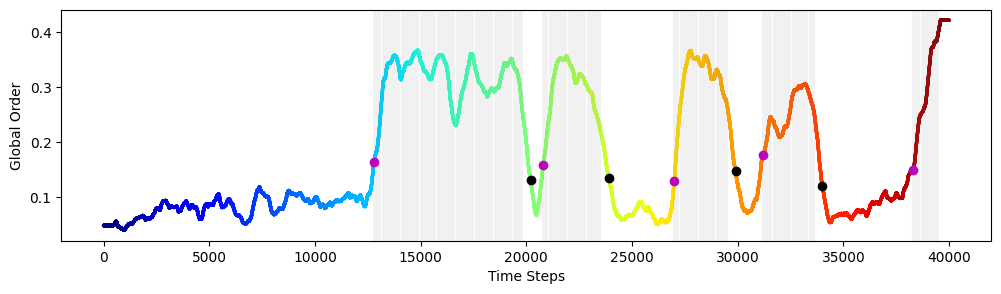

In [33]:
plot_transition(data[run],l['start_points'],l['stop_points'])

# For whole dataframe

In [7]:
def compute_param_df(data):
    c=0
    trans_count=0
    tran_per=[] # to store number of transitions per 100 iterations
    s_time=[]
    fpt=[]
    tran_time=[]
    while c<data.shape[1]: 
        l=compute_parameters(data[c])
        
        trans_count=trans_count+len(l['start_points'])
        if c%100==0 or c==data.shape[1]-1:
            tran_per.append(trans_count)

        s_time.append(compute_sync(l['start_points'],l['stop_points']))
        if len(l['start_points'])!=0:
            fpt.append(l['start_points'][0]*0.05)

        t_time=compute_transition_time(data[c],l['start_points'])
        for item in t_time:
            tran_time.append(item)
            
        c+=1

    param_dict=dict(zip(['tran_per','sync','trans','fpt'],[tran_per,s_time,tran_time,fpt]))
    return param_dict

In [90]:
h=compute_param_df(data)

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [7000, 36800]
37363


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [6500, 11000, 23800, 36600]
7223
24531
37440


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

16313
start [6400, 11700, 14100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


12086
15282


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [10000, 15500, 35600]
10949
16456
36669


In [97]:
len(h['trans'])
h['tran_per']
len(h['fpt'])

147

{'bodies': [<matplotlib.collections.PolyCollection at 0x75c37c9e25c0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x75c37c9e3670>,
 'cmins': <matplotlib.collections.LineCollection at 0x75c37c9e1480>,
 'cbars': <matplotlib.collections.LineCollection at 0x75c37c9e2410>,
 'cmedians': <matplotlib.collections.LineCollection at 0x75c37c9e16f0>}

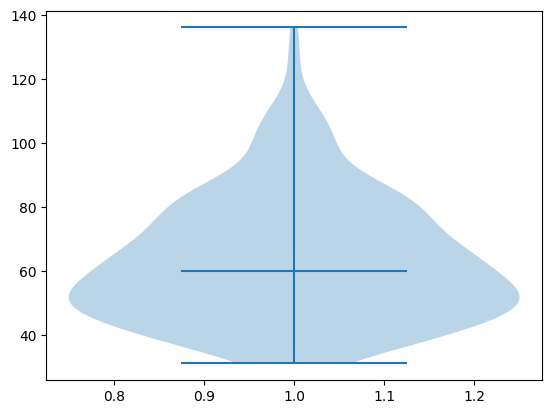

In [91]:
plt.violinplot(h['trans'],showmedians=True)

### sync state time


In [8]:
def compute_sync(start,stop): 
    t=[]
    st=0
    chunk_size=400
    if len(start)!=0 and len(stop)!=0:
        if len(start)==len(stop) or len(start)>len(stop):
            for _start,_stop in zip(start,stop):
                time = _stop+chunk_size-(_start-400)
                t.append(time)
    
        st=(sum(t)/len(t))*0.05
    return st

### Check sync time algo

In [41]:
s_time=compute_sync(l['start_points'],l['stop_points'])
s_time

0

### Compute transition time

In [9]:
def compute_transition_time(df,start): 
    window_size = 200
    _data=df.rolling(800, center=True).mean().ffill().bfill()
    # Define a function to calculate slope for a given window
    def calculate_slope(window):
        if len(window) < 2:  # Need at least two points to calculate slope
            return np.nan
        x = np.arange(0,len(window),1)
        y = window.values
        # Using numpy.polyfit for linear regression to get slope
        slope, intercept = np.polyfit(x, y, 1)
        return slope
    
    # Apply the slope calculation over a rolling window
    #rolling_slopes = _data[l_embed].rolling(window=window_size).apply(calculate_slope, raw=False)
    t_time=[]
    for k in start:
        rolling_slopes = _data[k:].rolling(window=window_size).apply(calculate_slope, raw=False)
        for i in rolling_slopes.index:
            if rolling_slopes[i] <0:
                print(i)
                c=i-1
                t_time.append(c)
                break

    
    t=[]
    if len(start)>0:
        for _init,_end in zip(start,t_time):
            time=_end-(_init-400)
            t.append(time)
    
    transition_time=[item*0.05 for item in t]
    
    return transition_time 

In [74]:
compute_transition_time(data[39],[16000])

17488


[94.35000000000001]

In [84]:
c=0
trans_count=0
s_time=[]
t_time=[]
while c<200: 
    l=compute_parameters(data[c])
    
    # trans_count=trans_count+len(l['start_points'])
    # s_time.append(compute_sync(l['start_points'],l['stop_points']))
    tran_time=compute_transition_time(data[c],l['start_points'])
    for item in tran_time: 
        t_time.append(item)
    
    c+=1
print(t_time)


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [7000, 36800]
37363


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [6500, 11000, 23800, 36600]
7223
24531
37440


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

16313
start [6400, 11700, 14100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


12086
15282


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [10000, 15500, 35600]
10949
16456
36669
[48.1, 56.1, 56.5, 61.95, 74.45, 56.050000000000004, 73.60000000000001, 65.85000000000001, 62.7, 43.650000000000006, 74.7, 45.150000000000006, 91.15, 63.1, 50.900000000000006, 53.050000000000004, 53.650000000000006, 59.5, 73.60000000000001, 55.150000000000006, 84.60000000000001, 60.550000000000004, 53.6, 61.300000000000004, 37.65, 63.85, 55.550000000000004, 51.95, 57.6, 50.050000000000004, 57.900000000000006, 45.550000000000004, 50.95, 116.15, 57.2, 66.5, 44.95, 55.5, 49.0, 72.05, 89.7, 89.0, 47.1, 59.5, 65.25, 58.150000000000006, 64.4, 73.75, 84.5, 55.900000000000006, 35.7, 45.0, 44.1, 48.650000000000006, 49.7, 44.550000000000004, 94.35000000000001, 69.55, 66.65, 69.35000000000001, 47.35, 40.300000000000004, 40.35, 92.55000000000001, 45.0, 94.35000000000001, 43.400000000000006, 50.0, 69.5, 48.300000000000004, 75.4, 66.45, 87.85000000000001, 50.6, 81.75, 49.150000000000006, 51.7, 65.60000000000001, 88.5, 86.55000000000001, 72.45, 82.3000000

{'bodies': [<matplotlib.collections.PolyCollection at 0x75c37dd30cd0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x75c378397a30>,
 'cmins': <matplotlib.collections.LineCollection at 0x75c36b0ac970>,
 'cbars': <matplotlib.collections.LineCollection at 0x75c36b0ac580>,
 'cmedians': <matplotlib.collections.LineCollection at 0x75c37d337d30>}

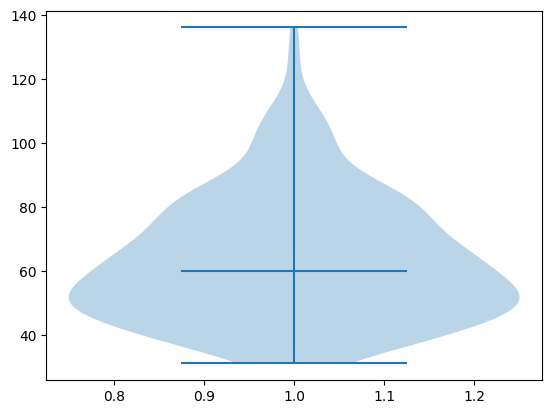

In [85]:
plt.violinplot(t_time,showmedians=True)

In [23]:
len(t_time)
s_t_array=np.asarray(s_time)

{'bodies': [<matplotlib.collections.PolyCollection at 0x76656091a9e0>],
 'cmedians': <matplotlib.collections.LineCollection at 0x76656091a410>}

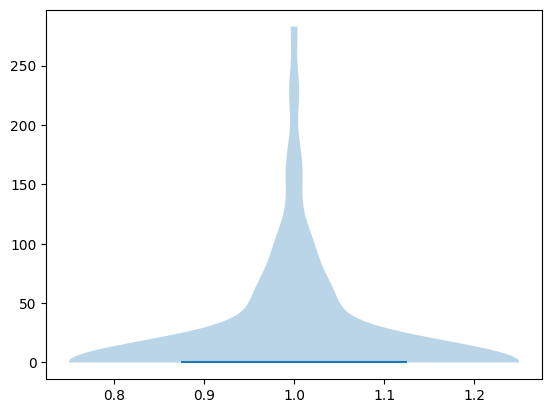

In [34]:
plt.violinplot(s_t_array[s_t_array<300],showmedians=True,showextrema=False)

In [98]:
data_folder = Path("../../data/results/processed/")
files=glob.glob(str(data_folder/"itr*.bz2"))

tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states
fpt_params={}
t_time=[]
for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")
    df_d.columns=range(0,df_d.shape[1])

    # Compute parameters
    params = compute_param_df(df_d)
    
    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params['trans']
    sync_params[f"{name_suffix}"] = params["sync"]
    fpt_params[f"{name_suffix}"] = params["fpt"]
    print(f'{f} DONE')


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [34800]
35125


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [9500, 15500, 19500, 26900]
16135


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

...

10756
12684
18296
30102
start [8200, 27300, 33100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


9094
28464
33969
start [34100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [6800]
8330
../../data/results/processed/itr_re.bz2 DONE


In [101]:
params['trans']


[78.30000000000001,
 44.150000000000006,
 69.25,
 50.25,
 67.75,
 68.25,
 86.5,
 70.65,
 113.4,
 62.1,
 98.30000000000001,
 93.55000000000001,
 37.85,
 37.550000000000004,
 57.25,
 44.150000000000006,
 82.35000000000001,
 49.550000000000004,
 68.3,
 44.35,
 36.85,
 49.7,
 53.6,
 51.550000000000004,
 68.15,
 32.35,
 40.050000000000004,
 67.4,
 62.400000000000006,
 50.400000000000006,
 37.35,
 29.900000000000002,
 57.400000000000006,
 62.95,
 62.5,
 62.1,
 39.75,
 50.900000000000006,
 37.4,
 36.550000000000004,
 45.75,
 57.400000000000006,
 49.650000000000006,
 50.400000000000006,
 68.3,
 57.35,
 53.800000000000004,
 74.3,
 57.300000000000004,
 63.45,
 63.6,
 72.0,
 73.15,
 50.150000000000006,
 83.75,
 71.7,
 80.80000000000001,
 64.2,
 60.550000000000004,
 64.9,
 86.15,
 55.2,
 63.550000000000004,
 79.65,
 78.85000000000001,
 61.650000000000006,
 86.55000000000001,
 46.35,
 48.550000000000004,
 79.75,
 75.9,
 84.55000000000001,
 54.45,
 55.0,
 68.7,
 75.2,
 43.5,
 33.75,
 41.050000000000

In [47]:
sync_params

{'bla': [0,
  0,
  0,
  55.0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  590.0,
  0,
  0,
  0,
  0,
  46.66666666666667,
  0,
  0,
  0,
  0,
  250.0,
  0,
  60.0,
  0,
  0,
  205.0,
  118.75,
  270.0,
  0,
  55.0,
  0,
  0,
  0,
  0,
  0,
  0,
  45.0,
  45.0,
  0,
  0,
  0,
  0,
  242.5,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  75.0,
  0,
  112.5,
  80.0,
  0,
  52.5,
  55.0,
  61.0,
  0,
  0,
  82.5,
  0,
  0,
  0,
  0,
  0,
  0,
  625.0,
  0,
  0,
  0,
  75.0,
  85.0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  75.0,
  0,
  0,
  0,
  0,
  35.0,
  0,
  45.0,
  852.5,
  0,
  112.5,
  50.0,
  0,
  0,
  0,
  92.5,
  0,
  0,
  0,
  222.5,
  0,
  260.0,
  0,
  0,
  0,
  0,
  88.33333333333334,
  0,
  0,
  167.5,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  50.0,
  0,
  0,
  0,
  0,
  100.0,
  0,
  0,
  0,
  310.0,
  0,
  45.0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  161

In [48]:
trans_params

{'bla': [1740.0,
  775.0,
  500.0,
  435.0,
  1350.0,
  1365.0,
  1405.0,
  315.0,
  595.0,
  315.0,
  890.0,
  540.0,
  1230.0,
  775.0,
  785.0,
  945.0,
  620.0,
  940.0,
  1030.0,
  1200.0,
  780.0,
  775.0,
  1610.0,
  1130.0,
  1485.0,
  495.0,
  810.0,
  315.0,
  990.0,
  330.0,
  905.0,
  505.0,
  565.0,
  830.0,
  1160.0,
  850.0,
  425.0,
  1720.0,
  1305.0,
  1090.0,
  930.0,
  1175.0,
  1770.0,
  475.0,
  1400.0,
  1665.0,
  255.0,
  415.0,
  660.0,
  930.0,
  710.0,
  590.0,
  1405.0,
  960.0,
  735.0,
  355.0,
  715.0,
  705.0,
  775.0,
  345.0,
  805.0,
  455.0,
  1435.0,
  220.0,
  560.0,
  1815.0,
  345.0,
  1310.0,
  1000.0,
  840.0,
  605.0,
  455.0,
  735.0,
  1935.0,
  715.0,
  985.0,
  335.0,
  385.0,
  600.0,
  405.0,
  705.0,
  1010.0,
  505.0,
  365.0,
  460.0,
  1420.0,
  470.0,
  495.0,
  1015.0,
  1430.0,
  395.0,
  515.0,
  1485.0,
  1320.0,
  650.0,
  445.0,
  1300.0,
  305.0,
  680.0,
  220.0,
  1570.0,
  420.0,
  305.0,
  1070.0,
  480.0,
  1180.0,
  475

In [119]:
reader.data_dump_pkl('tran_100.pkl',tranPer_params)

In [4]:

# removing all zero entries
reader.data_dump_pkl('sync_state.pkl',sync_params)

NameError: name 'sync_params' is not defined

In [121]:
reader.data_dump_pkl('trans_time.pkl',trans_params)

In [122]:
reader.data_dump_pkl('fpt.pkl',fpt_params)

In [5]:
sync_params=reader.data_read_pkl('sync_state.pkl')
trans_params=reader.data_read_pkl('trans_time.pkl')
tranPer_params=reader.data_read_pkl('tran_100.pkl')
fpt_params = reader.data_read_pkl('fpt.pkl')




In [6]:
node_order=np.array(["fn", "bla", "enti", "orbi", "peri", "pir", "re"])

non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]

non





array([1, 4, 5, 2, 3, 6, 0])

NameError: name 'fpt_node' is not defined

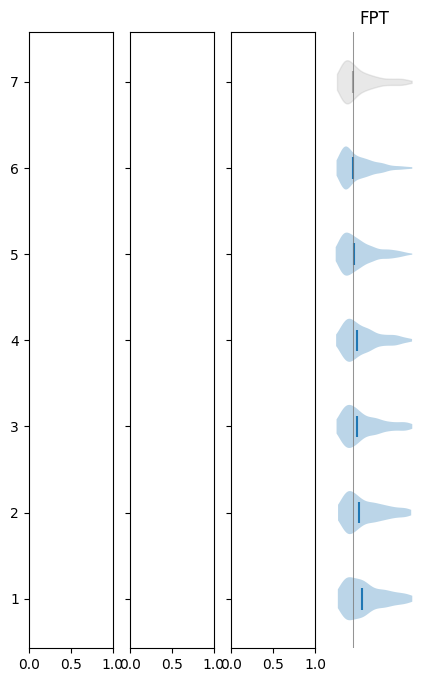

In [7]:
f,(ax1,ax2,ax3,ax4)= plt.subplots(1,4, figsize=(5,8), sharey=True)

# First passage time
_artists = ax4.violinplot(
    [fpt_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True
)
#ax4.set_yticks(np.arange(1, len(fpt_node) + 1))
#ax4.set_yticklabels(['*']*len(fpt_node), fontsize=30)

_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax4.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax4.set_xticks([])
#ax3.set_xlim(20, 100)
ax4.tick_params(axis="both", which="both", length=0)
ax4.set_title("FPT")
ax4.axvline(np.median(fpt_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


offset = 0.3   # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in fpt_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(fpt_params[node]) + offset
        y = idx
        ax4.text(x, y, '*',
                 ha='center',
                 va='center',
                 color='red',
                 fontsize=20)




# # number of transitions
_artists = ax3.violinplot(
    [trans_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True
)
# ax3.set_yticks(np.arange(1, len(node_order) + 1))
# ax3.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax3.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax3.set_xticks([])
ax3.set_xlim(20, 100)
ax3.tick_params(axis="both", which="both", length=0)
ax3.set_title("Transition time")
ax3.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.1   # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in trans_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(trans_params[node]) + offset
        y = idx
        ax4.text(x, y, '*',
                 ha='center',
                 va='center',
                 color='m',
                 fontsize=20)



# sync state
_artists = ax1.violinplot(
    [sync_params[k] for k in node_order[non] ],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 200)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("Sync state time")
ax1.axvline(np.median(sync_params['fn']), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.1   # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in sync_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(sync_params[node]) + offset
        y = idx
        ax4.text(x, y, '*',
                 ha='center',
                 va='center',
                 color='red',
                 fontsize=20)


# number of transitions
_artists = ax2.violinplot(
    [np.diff(np.array(tranPer_params[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.3   # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in tranPer_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(tranPer_params[node]) + offset
        y = idx
        ax4.text(x, y, '*',
                 ha='center',
                 va='center',
                 color='red',
                 fontsize=20)

f.subplots_adjust(wspace=0.8)
f.tight_layout()
#f.savefig('sign_comp.png')






In [109]:
tranPer_params['peri']

[0, 63, 146, 225, 301, 402, 477, 533, 618, 687, 782]

## check time

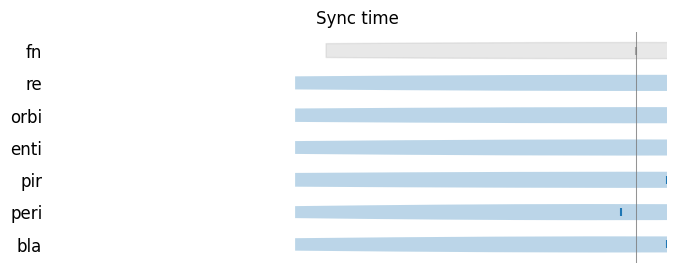

In [11]:
fig,ax3 = plt.subplots(figsize=(8,3))

_artists = ax3.violinplot(
    [sync_params[k] for k in node_order[non] ],
    vert=False,
    showextrema=False,
    showmedians=True
)
ax3.set_yticks(np.arange(1, len(node_order) + 1))
ax3.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax3.spines[["left", "right", "top", "bottom"]].set_visible(False)
#ax3_1=ax3.twinx()
#ax3_1.plot(0,0.5,'*')
ax3.set_xticks([])
ax3.set_xlim(0, 100)
ax3.tick_params(axis="both", which="both", length=0)
ax3.set_title("Sync time")
ax3.axvline(np.median(sync_params['fn'] ),c=cm.Greys(0.6, 0.8), lw=0.75)





## Remove zero entries from sync time

In [111]:
for k in node_order[non]:
    l=[]
    for i in sync_params[k]: 
        
        if i!=0: 
            l.append(i)
        
    sync_params[k]=l
   



In [51]:
np.max(sync_params['fn'])

1720.0

In [38]:
sync_params

{'bla': [55.0,
  590.0,
  46.66666666666667,
  60.0,
  205.0,
  118.75,
  270.0,
  55.0,
  45.0,
  45.0,
  242.5,
  75.0,
  80.0,
  55.0,
  61.0,
  82.5,
  75.0,
  85.0,
  75.0,
  35.0,
  45.0,
  852.5,
  112.5,
  50.0,
  92.5,
  222.5,
  260.0,
  88.33333333333334,
  167.5,
  50.0,
  100.0,
  310.0,
  45.0,
  161.66666666666669,
  167.5,
  140.0,
  45.0,
  20.0,
  97.5,
  45.0,
  527.5,
  70.83333333333334,
  210.0,
  107.5,
  45.0,
  148.75,
  50.0,
  390.0,
  50.0,
  1000.0,
  45.0,
  82.5,
  50.0,
  68.75,
  90.0,
  101.0,
  560.0,
  42.5,
  58.33333333333334,
  105.83333333333333,
  50.0,
  65.0,
  135.0,
  275.0,
  45.0,
  490.0,
  86.66666666666667,
  95.0,
  135.0,
  210.0,
  50.0,
  90.0,
  55.0,
  76.66666666666667,
  60.0,
  45.0,
  370.0,
  143.75,
  52.5,
  243.33333333333337,
  115.0,
  45.0,
  205.0,
  119.0,
  175.0,
  35.0,
  222.5,
  195.0,
  60.0,
  65.0,
  105.0,
  50.0,
  60.0,
  71.25,
  385.0,
  50.0,
  55.0,
  35.0,
  262.5,
  215.0,
  55.0,
  285.0,
  75.0,
  5

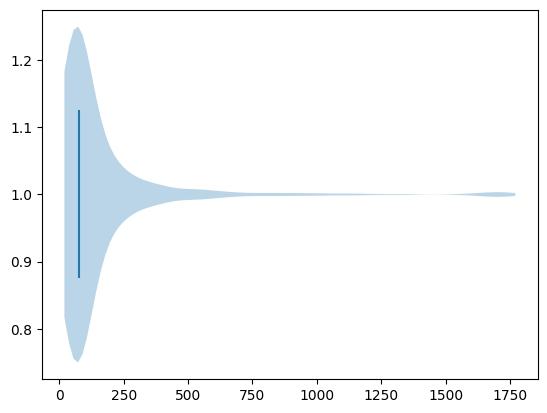

In [29]:
plt.violinplot([item for k in node_order[non] for item in sync_params[k] if item!=0],
    vert=False,
    showextrema=False,
    showmedians=True)

# ax3.set_yticks(np.arange(1, len(node_order) + 1))
# ax3.set_yticklabels(node_order[non], fontsize=12)
# _artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
# _artists["cmedians"].set_color(
#     list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
# )
ax3.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax3.set_xticks([])
#ax3.set_xlim(20, 100)
ax3.tick_params(axis="both", which="both", length=0)
ax3.set_title("transition time")
ax3.axvline(np.median([item for item in sync_params['fn'] if item!=0]), c=cm.Greys(0.6, 0.8), lw=0.75)

In [11]:
df_sync=df_sync.round(0)
df_sync[~(df_sync == 0.0).all(axis=1)]

,bla,enti,fn,orbi,peri,pir,re
0,0.0,0.0,50.0,0.0,0.0,0.0,0.0
3,55.0,45.0,0.0,0.0,0.0,0.0,183.0
4,0.0,0.0,0.0,0.0,0.0,65.0,0.0
5,0.0,0.0,77.0,95.0,0.0,0.0,0.0
6,0.0,0.0,62.0,0.0,0.0,0.0,138.0
...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,0.0,0.0,75.0
996,0.0,225.0,1315.0,0.0,0.0,0.0,94.0
997,0.0,0.0,0.0,162.0,0.0,0.0,163.0
998,0.0,0.0,50.0,75.0,0.0,0.0,0.0


In [27]:
a=[item for k in node_order[non] for item in sync_params[k] if item!=0]

In [28]:
len(a)

1725

## Man whitne U test to find if there is sinificant shift in median position



In [31]:



# simulate two distributions

sync_node=[]
group1 = np.asarray(sync_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(sync_params[k])
    
    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative='two-sided')
    if p<0.05: 
        sync_node.append(k)
    print(f" Sync state: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f'Significant node: {sync_node}')
    



    

 Sync state: bla Mann–Whitney U = 38006.0, p = 0.992
 Sync state: peri Mann–Whitney U = 43587.0, p = 0.206
 Sync state: pir Mann–Whitney U = 47010.5, p = 0.829
 Sync state: enti Mann–Whitney U = 56574.5, p = 0.728
 Sync state: orbi Mann–Whitney U = 55035.5, p = 0.927
 Sync state: re Mann–Whitney U = 66700.0, p = 0.712
 Sync state: fn Mann–Whitney U = 57122.0, p = 1.000
Significant node: []


In [33]:
trans_node=
[]
group1 = np.asarray(trans_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(trans_params[k])
    
    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative='two-sided')
    if p<0.05:
        trans_node.append(k)
    print(f" Duration: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f'Significant node: {trans_node}')



 Duration: bla Mann–Whitney U = 408813.5, p = 0.027
 Duration: peri Mann–Whitney U = 528219.0, p = 0.019
 Duration: pir Mann–Whitney U = 634659.5, p = 0.434
 Duration: enti Mann–Whitney U = 797628.0, p = 0.000
 Duration: orbi Mann–Whitney U = 785391.5, p = 0.475
 Duration: re Mann–Whitney U = 991569.5, p = 0.005
 Duration: fn Mann–Whitney U = 814088.0, p = 1.000
Significant node: ['bla', 'peri', 'enti', 're']


In [59]:
tranPer_node=[]
group1 = np.asarray(tranPer_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(tranPer_params[k])
    
    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative='two-sided',method='exact')
    if p<0.05: 
        
        
        tranPer_node.append(k)
    print(f" #transition: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")
print(f"Significant node: {tranPer_node}")



 #transition: bla Mann–Whitney U = 85.5, p = 0.116
 #transition: peri Mann–Whitney U = 83.0, p = 0.151
 #transition: pir Mann–Whitney U = 74.0, p = 0.401
 #transition: enti Mann–Whitney U = 68.5, p = 0.652
 #transition: orbi Mann–Whitney U = 65.5, p = 0.797
 #transition: re Mann–Whitney U = 51.5, p = 0.606
 #transition: fn Mann–Whitney U = 60.5, p = 1.000
Significant node: []


In [37]:
fpt_node=[]
group1 = np.asarray(fpt_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(fpt_params[k])
    
    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative='two-sided')
    if p<0.05: 
        fpt_node.append(k)
    print(f" FPT: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f'Significant node: {fpt_node}')


 FPT: bla Mann–Whitney U = 120613.5, p = 0.000
 FPT: peri Mann–Whitney U = 124427.5, p = 0.000
 FPT: pir Mann–Whitney U = 168573.5, p = 0.000
 FPT: enti Mann–Whitney U = 163811.0, p = 0.000
 FPT: orbi Mann–Whitney U = 229082.0, p = 0.581
 FPT: re Mann–Whitney U = 252453.0, p = 0.453
 FPT: fn Mann–Whitney U = 245000.0, p = 1.000
Significant node: ['bla', 'peri', 'pir', 'enti']


### Let's define confidence interval


In [38]:

def bootstrap_median_diff(x, y, B=5000):
    obs_diff = np.median(x) - np.median(y)
    N1, N2 = len(x), len(y)
    boot_diffs = np.empty(B)
    
    for i in range(B):
        x_star = np.random.choice(x, size=N1, replace=True)
        y_star = np.random.choice(y, size=N2, replace=True)
        boot_diffs[i] = np.median(x_star) - np.median(y_star)
    
    # two-sided p-value
    p_value = (np.sum(np.abs(boot_diffs) >= abs(obs_diff)) + 1) / (B + 1)
    # 95% CI
    ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
    return obs_diff, (ci_lower, ci_upper), p_value

group1 = np.asarray(fpt_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(fpt_params[k])
    obs, ci, p_boot = bootstrap_median_diff(group1, group2, B=10000)
    print(f" FPT: {k} Median diff = {obs:.2f}, 95% CI = [{ci[0]:.2f}, {ci[1]:.2f}], p = {p_boot:.3f}")
    

 FPT: bla Median diff = -202.50, 95% CI = [-247.50, -135.00], p = 0.429
 FPT: peri Median diff = -150.00, 95% CI = [-200.00, -75.00], p = 0.444
 FPT: pir Median diff = -90.00, 95% CI = [-140.00, -40.00], p = 0.476
 FPT: enti Median diff = -100.00, 95% CI = [-155.00, -42.50], p = 0.482
 FPT: orbi Median diff = -37.50, 95% CI = [-85.00, 17.50], p = 0.454
 FPT: re Median diff = 5.00, 95% CI = [-47.50, 60.00], p = 0.894
 FPT: fn Median diff = 0.00, 95% CI = [-45.00, 42.50], p = 1.000
